In [ ]:
import PBN_26
import matplotlib.pyplot as plt
import numpy as np
import random
import json
import networkx as nx
import seaborn as sns

In [ ]:
def sim(G, max_iteration):
    num_iteration = 0
    opinion_history = []
    while num_iteration < max_iteration and not G.consensus_reached(0.001) and not G.opinions_stabilized(0.0000001):
        for node in G.graph.nodes():
            neighbors = list(G.graph.neighbors(node))                
            weighted_sum = sum(G.weight_matrix[node][n] * G.agents[n].opinion for n in neighbors)
            new_opinion = weighted_sum / sum(G.weight_matrix[node][n] for n in neighbors)
            G.agents[node].opinion = new_opinion
        num_iteration += 1
        opinions_snapshot = [G.agents[node].opinion for node in G.graph.nodes()]
        opinion_history.append(opinions_snapshot)
    num_nodes = G.num_of_nodes
    time_steps = range(num_iteration)
    return opinion_history, num_nodes, time_steps

In [ ]:
def plot(opinion_history, time_steps, num_nodes):
    doc_1 = []
    for i in time_steps:
        doc_1.append(np.average(opinion_history[i]))
    plt.figure(figsize=(12, 8))
    for node_idx in range(num_nodes):
        opinion_values = [opinions[node_idx] for opinions in opinion_history]
        plt.plot(time_steps, opinion_values, alpha=0.1, color = "grey")
    plt.plot(time_steps, doc_1, alpha = 1, color = "black")
    plt.xlabel('Iteration', fontsize =25)
    plt.ylabel('Opinion', fontsize=25)
    plt.title('Opinion Dynamics Over Time',fontsize=25)
    plt.xticks(fontsize=25)
    plt.yticks(fontsize=25)
    plt.legend(fontsize=25)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
rounds = 100
E1_aveopinion_0 = []
ave_time_0 = []
max_iteration = 2000
for s in range(rounds):
    ave_single_sim = []
    random_state = np.random.RandomState(s)
    G = PBN_26.SFNetwork(100, 1000, 0, 20, 0, 0, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_0.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_0.append(ave_single_sim)
mean_opinion_0 = np.mean(E1_aveopinion_0, axis=0)
std_opinion_0 = np.std(E1_aveopinion_0, axis=0)

In [ ]:
rounds = 100
E1_aveopinion_50 = []
ave_time_50 = []
max_iteration = 2000
for s in range(rounds):
    ave_single_sim = []
    random_state = np.random.RandomState(s)
    G = PBN_26.SFNetwork(100, 1000, 0, 20, 0, 50, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_50.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_50.append(ave_single_sim)
mean_opinion_50 = np.mean(E1_aveopinion_50, axis=0)
std_opinion_50 = np.std(E1_aveopinion_50, axis=0)

In [ ]:
rounds = 100
E1_aveopinion_100 = []
ave_time_100 = []
max_iteration =2000
for s in range(rounds):
    ave_single_sim = []
    random_state = np.random.RandomState(s)
    G = PBN_26.SFNetwork(100, 1000, 0, 20, 0, 100, 0, random_state)
    opinion_history, num_nodes, time_steps = sim(G, max_iteration)
    ave_time_100.append(time_steps)
    for item in opinion_history:
        ave_single_sim.append(sum(item)/len(item))
    E1_aveopinion_100.append(ave_single_sim)
mean_opinion_100 = np.mean(E1_aveopinion_100, axis=0)
std_opinion_100 = np.std(E1_aveopinion_100, axis=0)

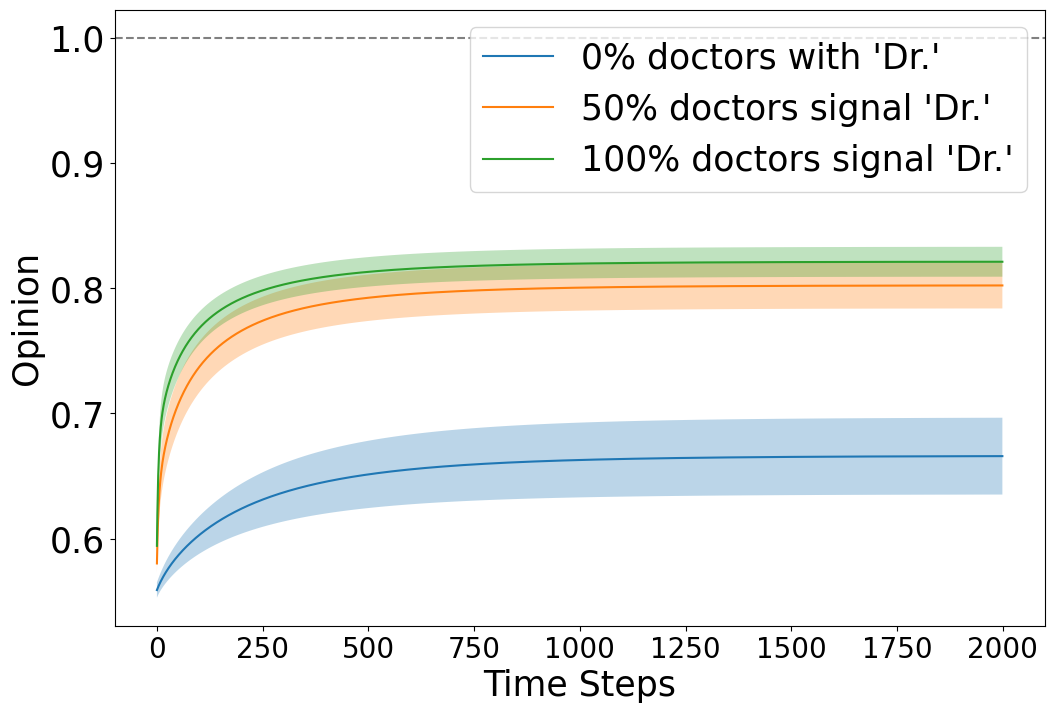

In [11]:
plt.figure(figsize=(12, 8))
plt.plot(mean_opinion_0, label="0% doctors with 'Dr.'")
plt.plot(mean_opinion_50, label="50% doctors signal 'Dr.'")
plt.plot(mean_opinion_100, label="100% doctors signal 'Dr.'")
# plt.fill_between(range(max_iteration), mean_opinion_s6 - std_opinion_s6, mean_opinion_s6 + std_opinion_s6, alpha=0.3, label='S6: ±1 Std Dev')
plt.fill_between(range(max_iteration), mean_opinion_0 - std_opinion_0, mean_opinion_0 + std_opinion_0, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_50 - std_opinion_50, mean_opinion_50 + std_opinion_50, alpha=0.3)
plt.fill_between(range(max_iteration), mean_opinion_100 - std_opinion_100, mean_opinion_100 + std_opinion_100, alpha=0.3)
plt.axhline(y = 1, color = 'grey', linestyle = 'dashed')
plt.xlabel('Time Steps', fontsize =25)
plt.ylabel('Opinion', fontsize=25)
# plt.title('E1 - Average Opinion Over Time on the PloBlog network',fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.legend(fontsize=25)
# plt.ylim(bottom=0.5)
# plt.grid(True)
plt.show()

In [ ]:
# Store results in json
data_to_store = {
    "E1_aveopinion_100": E1_aveopinion_100,
    "E1_aveopinion_50": E1_aveopinion_50,
    "E1_aveopinion_0": E1_aveopinion_0
}

with open("E1_PBN_opinions_data.json", "w") as f:
    json.dump(data_to_store, f)